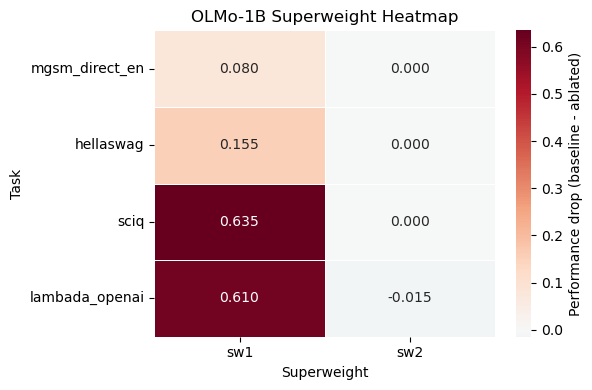

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../results/task_heatmaps/olmo1b_heatmap.csv")

category_order = ["math", "reasoning", "knowledge", "causal"]

task_order = (
    df[["task", "category"]]
    .drop_duplicates()
    .assign(category=lambda x: pd.Categorical(x["category"], categories=category_order, ordered=True))
    .sort_values(["category", "task"])["task"]
    .tolist()
)

pivot = df.pivot(index="task", columns="superweight_id", values="delta_abs").loc[task_order]

plt.figure(figsize=(6, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Performance drop (baseline - ablated)"}
)
plt.title("OLMo-1B Superweight Heatmap")
plt.xlabel("Superweight")
plt.ylabel("Task")
plt.tight_layout()
plt.show()